# Jaffle Shop database AI-agent

#### This notebook show-cases an OpenAI based AI-agent that allows non-technical users to query the Jaffle Shop with business questions in natural language.

#### Prerequisites: 
#### - Install necessary packages listed in `requirements.txt`.
#### - Set the environment variable OPENAI_API_KEY. If you run this from VS code, this can also be done by adding a .env file with the key.

#### First some imports:

In [1]:
from agent import DatabaseAgent
import duckdb
import argparse
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import os
from pprint import pprint
from prompts import build_sql_prompt, build_presentation_prompt_df, build_presentation_prompt_short
from prompts import build_chart_prompt, CHART_SCHEMA
from plots import build_plot
import numpy as np
from utils import rename_columns_human
from eval import PLOT_TEST_CASES, PLOT_TEST_CASES2, TEST_CASES3



#### Now, open a connection to the business database and initiate the agent. For now, we don't want the agent to log intermediate results, so we define null logger.


In [2]:
def log(message):
    pass

db_path = '../data/jaffle_shop.duckdb'
conn = duckdb.connect(db_path)
agent = DatabaseAgent(conn, log=log, temperature=0)

#### The full workflow is explained in the following, but the agent also runs it just calling `agent(question)`.

#### First, let's have a look at the database schema we are using by running `agent.get_schema_summary()`. Below, we can see that the schema has a few columns with categorical values, that the LLM needs to know the range of, such as customer.loyalty_tier and orders.status. 

#### To add these values to the LLM inputs, we run `agent.get_special_columns_content()`.

In [3]:
schema_summary = agent.get_schema_summary()
pprint(schema_summary)
special_columns = [{"table":"customers", "col": "loyalty_tier"},
                   {"table":"orders", "col": "status"}]
pprint(agent.get_special_columns_content(special_columns))

('customers\n'
 '  - customer_id: INTEGER\n'
 '  - first_name: VARCHAR\n'
 '  - last_name: VARCHAR\n'
 '  - email: VARCHAR\n'
 '  - loyalty_tier: VARCHAR\n'
 '  - created_at: TIMESTAMP\n'
 '\n'
 'order_items\n'
 '  - order_item_id: INTEGER\n'
 '  - order_id: INTEGER\n'
 '  - product_id: INTEGER\n'
 '  - quantity: INTEGER\n'
 '  - unit_price: DECIMAL(8,2)\n'
 '  - line_total: DECIMAL(10,2)\n'
 '\n'
 'orders\n'
 '  - order_id: INTEGER\n'
 '  - customer_id: INTEGER\n'
 '  - order_date: DATE\n'
 '  - status: VARCHAR\n'
 '  - total_amount: DECIMAL(10,2)\n'
 '  - order_channel: VARCHAR\n'
 '\n'
 'products\n'
 '  - product_id: INTEGER\n'
 '  - product_name: VARCHAR\n'
 '  - category: VARCHAR\n'
 '  - price: DECIMAL(8,2)\n'
 '  - description: VARCHAR')
[{'column': 'customers.loyalty_tier',
  'values': ['bronze', 'gold', 'silver', 'platinum']},
 {'column': 'orders.status', 'values': ['returned', 'cancelled', 'completed']}]


#### Next, we give the agent a question, from which the agent builds a prompt:

In [4]:
question =  "Who are our top 10 customers by total spend? Display the result in a bar chart showing total spend on the y-axis and customer name on the x-axis."
sql_prompt = build_sql_prompt(question, schema_summary, agent.special_columns)
print("Generated SQL Prompt:")
print(sql_prompt)

Generated SQL Prompt:

        You are an expert data analyst who writes SQL queries to answer questions about a database. 
        The question may contain information about plotting preferences, but you should ignore that for this prompt and focus only on writing a SQL query to answer the question.
        The database schema is as follows:
        Schema:
        customers
  - customer_id: INTEGER
  - first_name: VARCHAR
  - last_name: VARCHAR
  - email: VARCHAR
  - loyalty_tier: VARCHAR
  - created_at: TIMESTAMP

order_items
  - order_item_id: INTEGER
  - order_id: INTEGER
  - product_id: INTEGER
  - quantity: INTEGER
  - unit_price: DECIMAL(8,2)
  - line_total: DECIMAL(10,2)

orders
  - order_id: INTEGER
  - customer_id: INTEGER
  - order_date: DATE
  - status: VARCHAR
  - total_amount: DECIMAL(10,2)
  - order_channel: VARCHAR

products
  - product_id: INTEGER
  - product_name: VARCHAR
  - category: VARCHAR
  - price: DECIMAL(8,2)
  - description: VARCHAR
            Some columns 

#### The prompt is then fed by the agent into an llm, which returns a SQL-statement. The SQL-statement is tested by the guardrails, which verify that the statement starts with "select" and do not contain any of the words "insert", "update", "delete", "drop", "alter". After checking the statement, it is fed to the database which returns some output.

In [5]:
sql_response_dict = agent.sql_query(sql_prompt)
print(f"Query succesful: {str(sql_response_dict['success'])}\n")
if sql_response_dict['success']:
    print(f"Query string:\n{sql_response_dict['sql_query']}\n")
    print(f"DB output: \n{sql_response_dict['query_result']}\n")
else:
    error_text = f"Encountered an error of type {sql_response_dict.get('error type', 'UNKNOWN')}: {sql_response_dict.get('error text', 'No error text provided.')}"
    print(error_text)


Query succesful: True

Query string:
SELECT c.first_name, c.last_name, SUM(o.total_amount) AS total_spend
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.first_name, c.last_name
ORDER BY total_spend DESC
LIMIT 10

DB output: 
  first_name last_name  total_spend
0       Jack     Moore       1062.5
1       Ella    Martin        619.0
2       Luna    Wright        547.0
3     Olivia  Thompson        537.5
4    Addison    Rivera        535.5
5     Olivia     Smith        518.5
6       Ella      Hill        508.0
7    William    Thomas        492.0
8    William     Moore        488.0
9      Jacob  Martinez        486.0



#### Based on the output type, we decide whether we should present the results as a table or as a string. If there is only one row in the dataframe, we choose a text-presentation, and if there are more, we present the result as a table.


In [6]:
#query_result = sql_response_dict["query_result"]
query_result = rename_columns_human(sql_response_dict["query_result"])
sql_query = sql_response_dict["sql_query"]
result_columns_and_DT_dict = {col: str(dtype) for col, dtype in zip(query_result.columns, query_result.dtypes)}
if len(query_result) == 1:
            presentation_type = "PRESENTATION: TEXT"
else: presentation_type = "PRESENTATION: TABLE"
print(f"Determined presentation type: {presentation_type}")
        

Determined presentation type: PRESENTATION: TABLE


#### If the presentation is to be in a text format, the agent asks the LLM for a text with one prompt, and if it is to be presented as a table, the agent asks for another.

#### In the case that the presentation type is a table, the agent asks the LLM to specify which kind of plot is suitable.

Prompt used for presentation generation: You are a data analyst, and you have just executed the following SQL query against a DuckDB database.
    Instructions:
        - write a short introductory text to present the data in the DataFrame, based on the user question and the SQL query 
        - the data will be presented in a dataframe after the text
        - Do not use any type of markup (e.g. markdown, html, etc.) in your response. Return plain text only.
        The text should have three sections:
        BRIEF: <one sentence non-technical description of the results. It should focus on explaining the numbers in the DataFrame.>
        IN-DEPTH: <2-4 sentences non-technical summary of the results, focussing on any interesting patterns, trends, or outliers in the data. It should focus on explaining the numbers in the DataFrame.>
        METHODOLOGY: <brief non-technical summary of any methodological choices, assumptions, or interpretations you made in writing the SQL query>

      

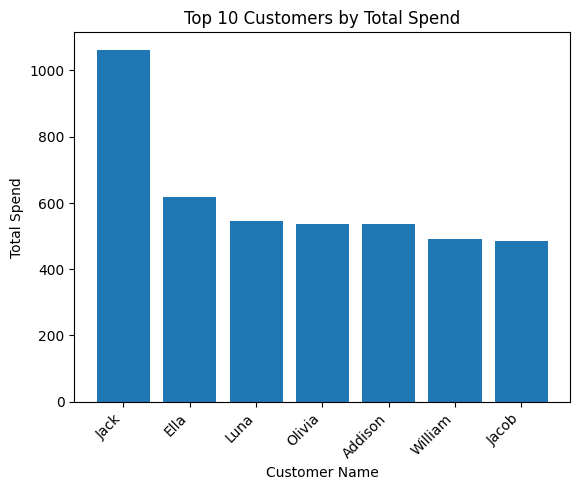

In [7]:
if presentation_type == "PRESENTATION: TEXT":
    to_text_prompt = build_presentation_prompt_short(question, agent.schema_summary, sql_query, query_result.head())
    print("Prompt used for presentation generation:", to_text_prompt)   

    text_output = agent.get_llm_response(to_text_prompt)
    print("Text Output:", text_output)   

elif presentation_type == "PRESENTATION: TABLE":
    df_presentation_prompt = build_presentation_prompt_df(question, agent.schema_summary, sql_query, query_result.head())
    print("Prompt used for presentation generation:", df_presentation_prompt, "\n")
    df_intro_text = agent.get_llm_response(df_presentation_prompt)
    text_output = f"{df_intro_text}\n\n{query_result.to_string(index=False)}"
    print("Table presentation output:")
    print(text_output, "\n")
    chart_prompt = build_chart_prompt(question=question, sql=sql_query, columns=result_columns_and_DT_dict, preview_rows=query_result.head())
    chart_response_dict = agent.get_llm_response_jsonschema(chart_prompt, json_schema=CHART_SCHEMA)
    print("Generated chart response dict:")
    pprint(chart_response_dict)
    fig, ax = build_plot(chart_response_dict, query_result, log=log)
    #display(fig)

#### The workflow is wrapped up in `agent(question)`, which returns a dict with the results:

In [8]:
result_dict = agent(question)

Final result:
BRIEF: The data shows the top 10 customers ranked by their total spending, with Jack Moore leading the list with a total spend of 945.5.

IN-DEPTH: The analysis reveals that Jack Moore is the highest spender among the customers, with a significant lead over the others at 945.5. Ella Martin and Ella Hill follow, with total spends of 495.5 and 471.5, respectively. Notably, there are two customers with the first name Olivia, both appearing in the top 10, indicating a possible trend or coincidence in spending habits. The total spend values gradually decrease from the top spender to the tenth, Luna Wright, who has a total spend of 424.5.

METHODOLOGY: The SQL query was designed to identify the top 10 customers by total spend by joining the customers and orders tables on customer_id, filtering for completed orders, and summing the total_amount for each customer. The results were grouped by customer names and ordered by total spend in descending order to highlight the highest sp

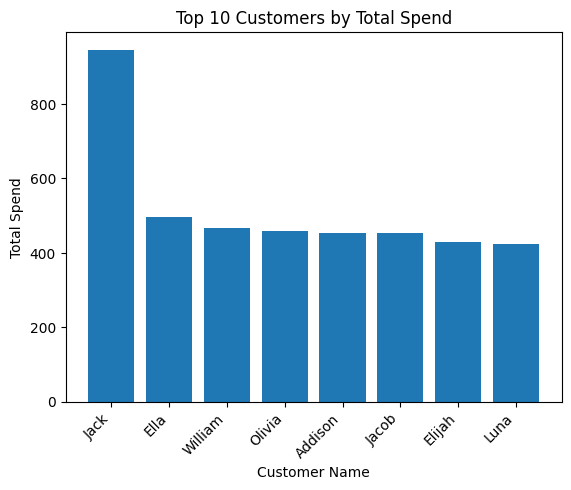

In [10]:
if result_dict["success"]:
    print("Final result:")
    print(result_dict["text"])
    print(result_dict['sql query'])
    fig, ax = result_dict.get("chart", [None, None])
    if fig is not None:
        display(fig)
else:
    print("Failed to get a result.")
    print(f"Error details: {result_dict.get('error type', 'UNKNOWN')}: {result_dict.get('error text', 'No error text provided.')}")

#### Now let's loop over all the test cases

In [11]:
test_case_results = []
for test_case_result in PLOT_TEST_CASES:
    test_dict = test_case_result.copy()
    print(f"Running test case: {test_case_result['id']}")
    question = test_case_result["question"]
    response = agent(question)
    #print("Response:")
    #pprint(response)
    #print("\n\n")
    test_dict["response"] = response
    test_case_results.append(test_dict)


Running test case: plot_01
Running test case: plot_02
Running test case: plot_03
Running test case: plot_04
Running test case: plot_05
Running test case: plot_06
Running test case: plot_07
Running test case: plot_08


--------------------------------------------------
test id: plot_01
Question: What was our monthly revenue over time?
BRIEF: The monthly revenue fluctuated over the observed period, with peaks and troughs at various points.

IN-DEPTH: The data shows that monthly revenue varied significantly from January 2024 to February 2026. Notably, July 2024 saw the highest revenue at 2519.5, while February 2024 had the lowest at 1401.5. There is a general trend of revenue increasing towards the middle of each year, with some months consistently outperforming others. The revenue figures suggest seasonal patterns or other external factors influencing sales.

METHODOLOGY: The SQL query was designed to calculate the total revenue for each month by summing the total amounts of completed orders. The data was grouped by month, using the DATE_TRUNC function to aggregate the order dates, and ordered chronologically to provide a clear timeline of monthly revenue changes.

     Month  Monthly Revenue
2024-01-

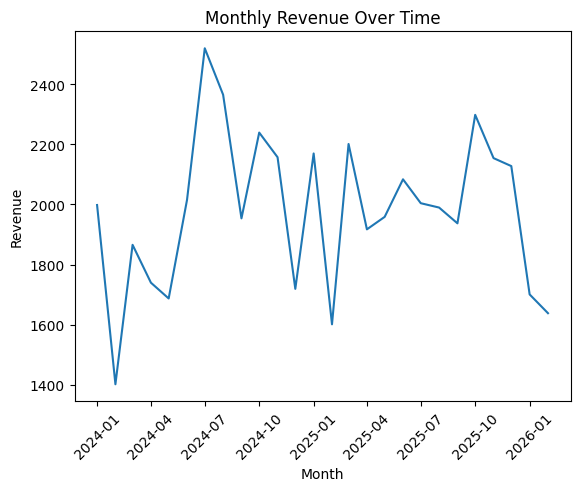

--------------------------------------------------
test id: plot_02
Question: Show monthly revenue and order count over time.
BRIEF: The data shows monthly revenue and order count from January 2024 to February 2026, with fluctuations in both metrics over time.

IN-DEPTH: The monthly revenue and order count exhibit noticeable variations throughout the observed period. July 2024 and October 2025 stand out with the highest revenues of $2,519.5 and $2,298.0, respectively, and correspondingly high order counts. Conversely, February 2024 and February 2026 show lower revenues and order counts, indicating potential seasonal trends or other influencing factors. The data suggests a general pattern of increased activity during mid-year months, with some months consistently outperforming others in terms of both revenue and order volume.

METHODOLOGY: The SQL query aggregates data by month, focusing only on completed orders to ensure accuracy in revenue and order count. It uses the DATE_TRUNC funct

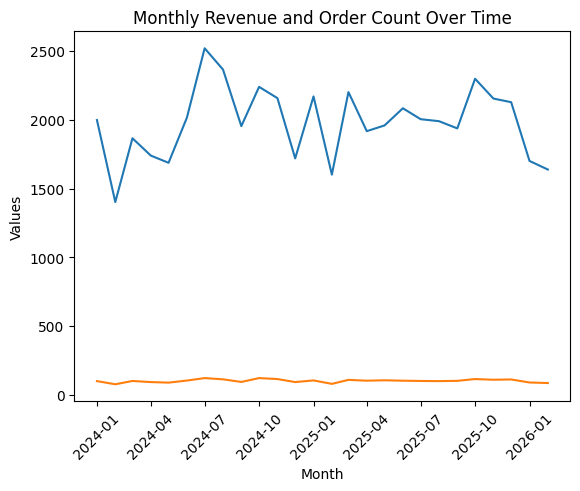

--------------------------------------------------
test id: plot_03
Question: What are the top 10 products by revenue?
BRIEF: The top-selling product by revenue is the Spicy Beef Jaffle, generating a total of 5984.0 in revenue.

IN-DEPTH: The data reveals that jaffles dominate the top revenue-generating products, with five different jaffle varieties appearing in the top six positions. The Spicy Beef Jaffle leads the list, closely followed by the BBQ Chicken Jaffle and Mushroom & Brie Jaffle. Non-jaffle items like Sweet Potato Fries, Chocolate Brownie, Banana Bread, and Iced Latte also make it to the top 10, indicating a diverse range of popular products. The revenue figures show a gradual decline from the top product to the tenth, suggesting a relatively even distribution of sales among these top items.

METHODOLOGY: The SQL query was designed to calculate the total revenue for each product by summing up the line totals from the order items table, joined with the products table to get 

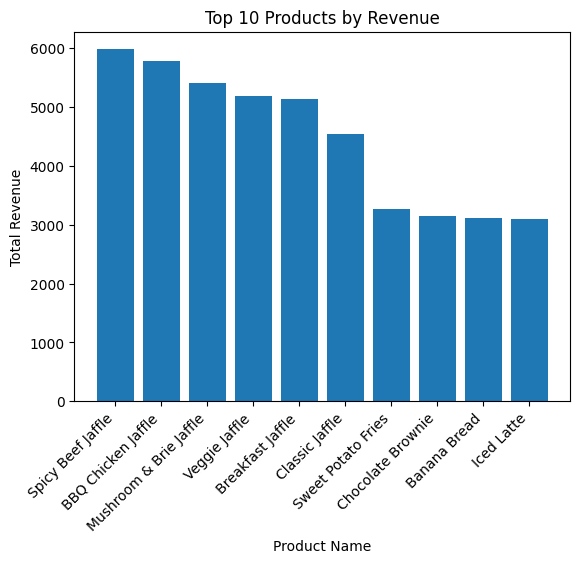

--------------------------------------------------
test id: plot_04
Question: Show revenue by year and product.
BRIEF: The data shows the revenue generated by different products across the years 2024, 2025, and 2026, with notable variations in revenue figures for each product and year.

IN-DEPTH: In 2024, the "BBQ Chicken Jaffle" and "Spicy Beef Jaffle" were among the top revenue-generating products, with revenues of 2761.5 and 2563.0 respectively. The year 2025 saw "Spicy Beef Jaffle" leading with 2981.0 in revenue, followed by "Mushroom & Brie Jaffle" at 2580.0. By 2026, the revenue figures for most products decreased significantly, with "Spicy Beef Jaffle" still leading but only generating 440.0. This trend suggests a decline in sales or a shift in consumer preferences over the years.

METHODOLOGY: The SQL query extracted the year from the order date and aggregated the revenue by summing up the line totals for each product. The data was grouped by year and product name to provide a 

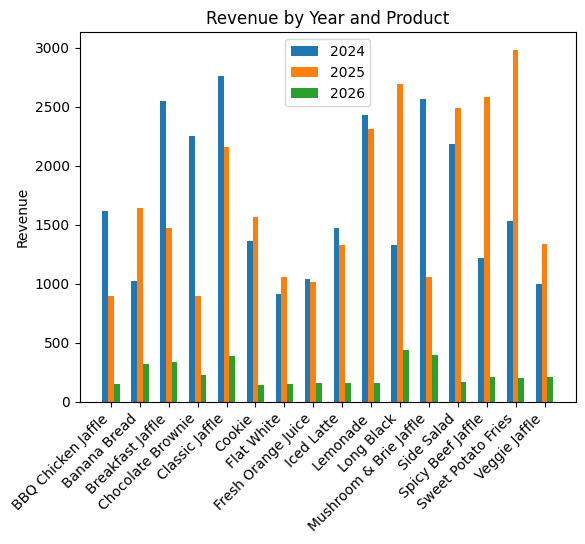

--------------------------------------------------
test id: plot_05
Question: Show the composition of revenue by year across products.
BRIEF: The data shows the revenue generated by different products over the years 2024, 2025, and 2026, with the highest revenue in each year coming from various jaffle products.

IN-DEPTH: In 2024, the BBQ Chicken Jaffle led the revenue with 2436.0, closely followed by the Mushroom & Brie Jaffle and Spicy Beef Jaffle. By 2025, the Spicy Beef Jaffle took the lead with 2772.0, indicating a shift in consumer preference or marketing focus. The revenue for 2026 shows a significant drop across all products, with the Spicy Beef Jaffle still leading but with only 363.0, suggesting a possible seasonal trend or market change. Notably, jaffle products consistently appear at the top of the revenue list, highlighting their popularity.

METHODOLOGY: The SQL query was designed to extract and sum the revenue for each product by year from completed orders. It grouped th

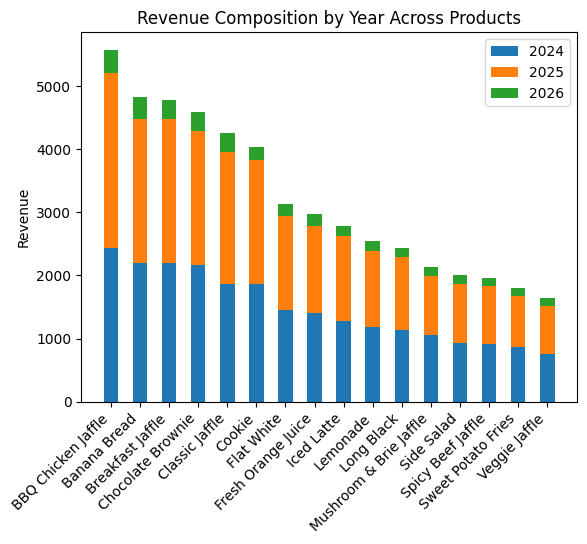

--------------------------------------------------
test id: plot_06
Question: How many completed orders did we have by month?
BRIEF: The data shows the number of completed orders per month, with figures ranging from 77 to 122 orders.

IN-DEPTH: The monthly completed orders exhibit some fluctuations over the observed period. Notably, July 2024 and October 2024 both saw the highest number of completed orders at 122, while February 2024 had the lowest with 77. There is a general trend of increased orders during the middle months of each year, with some variability. The data suggests a possible seasonal pattern, with peaks and troughs occurring at similar times each year.

METHODOLOGY: The SQL query was designed to count the number of orders with a 'completed' status, grouped by month. The use of DATE_TRUNC allowed for aggregation of order data by month, and the results were ordered chronologically to provide a clear view of trends over time.

     Month  Completed Orders Count
2024-01-01 

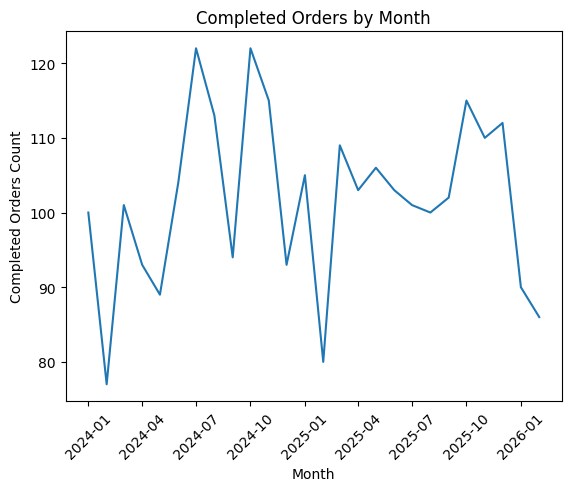

--------------------------------------------------
test id: plot_07
Question: How many orders do we have in total?
BRIEF: There are a total of 3,000 orders in the database.

METHODOLOGY: To determine the total number of orders, I used a simple SQL query that counts all entries in the 'orders' table. This approach assumes that each row in the 'orders' table represents a unique order, which is a standard assumption given the schema provided.
--------------------------------------------------
test id: plot_08
Question: Who are our best customers?
Encountered an error of type AMBIGUOUS: AMBIGUOUS: Who are our best customers?


In [11]:
for test_case_result in test_case_results:
    question = test_case_result["question"]
    response = test_case_result["response"]
    print("-"*50)
    print("test id:", test_case_result["id"])
    print(f"Question: {question}")
    
    if response["success"]:
        print(response["text"])
        if response["presentation_type"] == "TABLE" and (response.get("chart", None) is not None):
            print("Saving and displaying chart...")
            fig, ax = response["chart"]
            display(fig)
            #plt.show(fig)
            #plt.close()
        
    else: 
        error_text = f"Encountered an error of type {response.get('error type', 'UNKNOWN')}: {response.get('error text', 'No error text provided.')}"
        log(error_text)
        print(error_text)


In [12]:
#conn.close()